In [304]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving testes.csv to testes (21).csv


In [305]:
df = pd.read_csv('testes.csv')

In [306]:
df_bfs = df[df['algorithm'] == 'BFS'].drop(columns=['algorithm']).reset_index(drop=True)
df_a_star = df[df['algorithm'] == 'A*'].drop(columns=['algorithm']).reset_index(drop=True)

In [307]:
display(df_bfs.head())

,vertices,probability,oriented,iteration,tot_dist,attempt_cnt
0,10,10,0,1,80,10
1,10,10,0,2,-1,2
2,10,10,0,5,-1,5
3,10,10,0,1,-1,1
4,10,10,0,1,-1,1


In [308]:
display(df_a_star.head())

,vertices,probability,oriented,iteration,tot_dist,attempt_cnt
0,10,10,0,4,80,37
1,10,10,0,2,-1,2
2,10,10,0,5,-1,5
3,10,10,0,1,-1,1
4,10,10,0,1,-1,1


In [309]:
import matplotlib.pyplot as plt

# Initialize counters
a_star_smaller = 0
bfs_smaller = 0
both_negative_one = 0
both_equal = 0

# Assuming df_bfs and df_a_star have the same length due to previous reset_index
# and that corresponding rows represent the same graph run.
for i in range(len(df_bfs)):
    tot_dist_bfs = df_bfs.loc[i, 'tot_dist']
    tot_dist_a_star = df_a_star.loc[i, 'tot_dist']

    if tot_dist_bfs == -1 and tot_dist_a_star == -1:
        both_negative_one += 1
    elif tot_dist_a_star < tot_dist_bfs:
        a_star_smaller += 1
    elif tot_dist_bfs < tot_dist_a_star:
        bfs_smaller += 1
    elif tot_dist_bfs == tot_dist_a_star:
        both_equal += 1

# Create a pandas Series for easy plotting
comparison_counts = pd.Series({
    'A*': a_star_smaller,
    'BFS': bfs_smaller,
    # 'Both -1': both_negative_one,
    'A* e BFS': both_equal
})

print("Comparison Results:")
display(comparison_counts)


Comparison Results:


,0
A*,3403
BFS,0
A* e BFS,2348


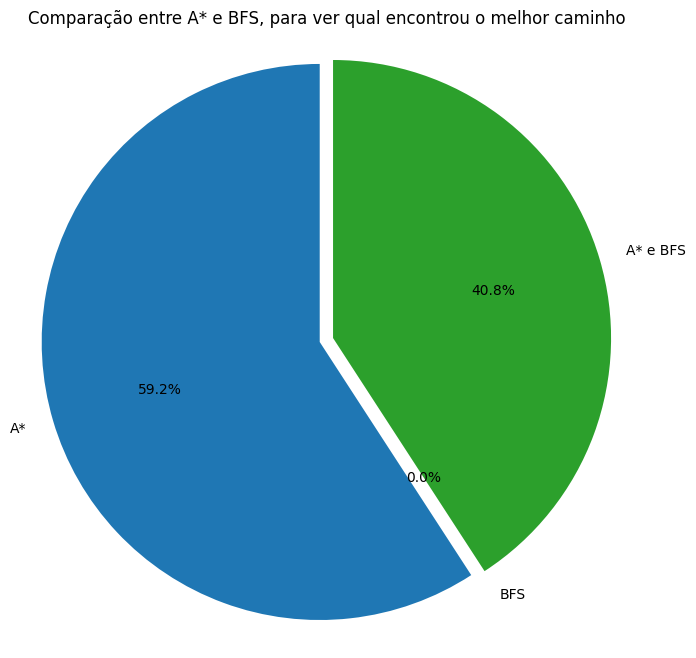

In [310]:
# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(comparison_counts, labels=comparison_counts.index, autopct='%1.1f%%', startangle=90, explode=[0.05 if count == comparison_counts.max() else 0 for count in comparison_counts])
plt.title('Comparação entre A* e BFS, para ver qual encontrou o melhor caminho')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Comparison of Mean `attempt_cnt` and Mean `iteration`

In [311]:
print("Média de tentativas de inserções na fronteira (BFS):", df_bfs['attempt_cnt'].mean())
print("Média de tentativas de inserções na fronteira (A*):", df_a_star['attempt_cnt'].mean())

print("\nMédia de iterações (BFS):", df_bfs['iteration'].mean())
print("Média de iterações (A*):", df_a_star['iteration'].mean())

Média de tentativas de inserções na fronteira (BFS): 32161.029666666665
Média de tentativas de inserções na fronteira (A*): 3481.3955

Média de iterações (BFS): 100.75333333333333
Média de iterações (A*): 13.536166666666666
